# Feature Engineering

The raw BNPL tables — orders, installments, payments, devices — don't directly tell us which transactions are fraudulent. The signal is buried in *patterns*: a customer who places 6 orders in 3 days from a VPN, whose device was previously associated with a defaulted account, and whose payment path jumped from current to 90+ DPD in one cycle. This notebook extracts those patterns into 50+ numeric features at the order level, maintaining strict point-in-time correctness to avoid data leakage.

Point-in-time correctness matters here more than in most ML problems. BNPL fraud is *sequential*: a bust-out fraudster builds a clean history of 3–5 small repaid orders before triggering a high-value default. If we accidentally let future payment outcomes leak into features for past orders, we'd train a model that looks brilliant in backtesting but is useless in production where we must decide *at order time* whether to approve.

Every feature computed below uses only information available strictly before or at the moment the order was placed. We achieve this through sorted cumulative operations (`cumsum`, `shift`, `expanding`) rather than global aggregations.

In [1]:
import os, sqlite3, warnings, time
import numpy as np
import pandas as pd
pd.options.future.infer_string = False
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

t_start = time.time()

DB_CLEAN = "../data/bnpl_clean.db"
DB_RAW = "../data/bnpl.db"
DB_PATH = DB_CLEAN if os.path.exists(DB_CLEAN) else DB_RAW
print(f"Using database: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
customers = pd.read_sql("SELECT * FROM customers", conn)
merchants = pd.read_sql("SELECT * FROM merchants", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
plans = pd.read_sql("SELECT * FROM payment_plans", conn)
installments = pd.read_sql("SELECT * FROM installments", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
decisions = pd.read_sql("SELECT * FROM credit_decisions", conn)
devices = pd.read_sql("SELECT * FROM device_fingerprints", conn)
disputes = pd.read_sql("SELECT * FROM disputes", conn)
segments = pd.read_sql("SELECT * FROM customer_segments_ground_truth", conn)
conn.close()

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders = orders.sort_values(["customer_id", "order_date"]).reset_index(drop=True)
orders["order_seq"] = orders.groupby("customer_id").cumcount() + 1

plans["start_date"] = pd.to_datetime(plans["start_date"])
plans["end_date"] = pd.to_datetime(plans["end_date"])
installments["due_date"] = pd.to_datetime(installments["due_date"])
payments["payment_date"] = pd.to_datetime(payments["payment_date"])
decisions["decision_timestamp"] = pd.to_datetime(decisions["decision_timestamp"])

print(f"Orders: {len(orders):,}  |  Customers: {orders['customer_id'].nunique():,}  |  Merchants: {orders['merchant_id'].nunique():,}")
print(f"Plans: {len(plans):,}  |  Installments: {len(installments):,}  |  Payments: {len(payments):,}")
print(f"Disputes: {len(disputes):,}  |  Devices: {len(devices):,}")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Using database: ../data/bnpl_clean.db
Orders: 155,750  |  Customers: 50,000  |  Merchants: 500
Plans: 138,420  |  Installments: 855,758  |  Payments: 619,049
Disputes: 7,060  |  Devices: 138,420


## Target Variable

We use a **probabilistic, order-level fraud label** generated during data synthesis rather than a simple `order_status == 'defaulted'` flag. This design choice matters: in reality, not every order from a fraudulent actor is itself fraudulent (a bust-out customer builds trust with legitimate early orders), and some legitimate customers commit opportunistic fraud on individual orders.

The `order_fraud_labels` ground truth table assigns fraud probability based on customer segment and fraud pattern, then samples a binary label per order. This produces realistic label noise — exactly what production fraud models face — and prevents the model from trivially memorizing segment membership.

In [2]:
conn_raw = sqlite3.connect(DB_RAW)
fraud_labels = pd.read_sql("SELECT order_id, is_fraud FROM order_fraud_labels", conn_raw)
conn_raw.close()
orders = orders.merge(fraud_labels, on="order_id", how="left")
orders["is_fraud"] = orders["is_fraud"].fillna(0).astype(int)

print(f"Fraud rate: {orders['is_fraud'].mean():.3%} ({orders['is_fraud'].sum():,} / {len(orders):,})")

fm = orders[["order_id", "customer_id", "merchant_id", "order_amount",
             "order_date", "order_status", "channel", "order_seq", "is_fraud"]].copy()

Fraud rate: 6.069% (9,453 / 155,750)


## Payment Behaviour

The strongest predictor of future default in BNPL is past payment behavior. A customer who has missed 3 of their last 10 installments is fundamentally different from one with a clean history — even if both have the same credit score. We compute rolling DPD statistics, on-time rates, and cumulative missed counts.

First-payment-default (FPD) deserves special attention. Affirm's public filings identify FPD as the single highest-signal indicator of bust-out fraud: a customer who defaults on their very first installment of a plan almost never intended to pay. We flag this at the *plan* level, then roll it up to the customer's history at order time.

Why cumulative rather than global averages? Because a fraudster's profile *changes over time*. Their first 3 orders have perfect payment history (the grooming phase). A global average would dilute the signal from recent deterioration. Cumulative metrics computed at each order capture the trajectory.

In [3]:
inst_plan = installments.merge(plans[["plan_id", "order_id"]], on="plan_id", how="left")
inst_plan = inst_plan.merge(
    orders[["order_id", "customer_id", "order_date"]].rename(columns={"order_date": "plan_order_date"}),
    on="order_id", how="left"
)

# For each current order, find all installments from PRIOR orders by the same customer
# that were due before the current order's date
inst_for_join = inst_plan[["customer_id", "installment_id", "status", "days_past_due",
                           "due_date", "installment_number", "order_id"]].copy()
inst_for_join["is_missed"] = (inst_for_join["status"] == "missed").astype(int)
inst_for_join["is_late"] = (inst_for_join["status"] == "late").astype(int)
inst_for_join["is_paid"] = (inst_for_join["status"] == "paid").astype(int)

# Aggregate installment stats per customer per originating order
order_inst_stats = inst_for_join.groupby(["customer_id", "order_id"]).agg(
    n_inst=("installment_id", "count"),
    n_missed=("is_missed", "sum"),
    n_late=("is_late", "sum"),
    n_paid=("is_paid", "sum"),
    sum_dpd=("days_past_due", "sum"),
    max_dpd=("days_past_due", "max"),
).reset_index()

# Merge with order dates and sort to compute cumulative stats
order_inst_stats = order_inst_stats.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
order_inst_stats = order_inst_stats.sort_values(["customer_id", "order_date"]).reset_index(drop=True)

# Cumulative sums SHIFTED by 1 (only prior orders count)
for col in ["n_inst", "n_missed", "n_late", "n_paid", "sum_dpd", "max_dpd"]:
    order_inst_stats[f"cum_{col}"] = order_inst_stats.groupby("customer_id")[col].cumsum().shift(1)
    order_inst_stats.loc[order_inst_stats.groupby("customer_id").head(1).index, f"cum_{col}"] = np.nan

# Reindex to use groupby-aware shift
order_inst_stats["cum_n_inst"] = order_inst_stats.groupby("customer_id")["n_inst"].cumsum() - order_inst_stats["n_inst"]
order_inst_stats["cum_n_missed"] = order_inst_stats.groupby("customer_id")["n_missed"].cumsum() - order_inst_stats["n_missed"]
order_inst_stats["cum_n_late"] = order_inst_stats.groupby("customer_id")["n_late"].cumsum() - order_inst_stats["n_late"]
order_inst_stats["cum_n_paid"] = order_inst_stats.groupby("customer_id")["n_paid"].cumsum() - order_inst_stats["n_paid"]
order_inst_stats["cum_sum_dpd"] = order_inst_stats.groupby("customer_id")["sum_dpd"].cumsum() - order_inst_stats["sum_dpd"]

plan_stats = order_inst_stats[["order_id", "cum_n_inst", "cum_n_missed", "cum_n_late",
                                "cum_n_paid", "cum_sum_dpd"]].copy()
plan_stats.columns = ["order_id", "total_installments_before", "missed_installments_before",
                       "late_installments_before", "paid_installments_before", "sum_dpd_before"]

plan_stats["mean_dpd_before"] = plan_stats["sum_dpd_before"] / plan_stats["total_installments_before"].replace(0, np.nan)
plan_stats["ontime_rate"] = plan_stats["paid_installments_before"] / plan_stats["total_installments_before"].replace(0, np.nan)
plan_stats["missed_rate"] = plan_stats["missed_installments_before"] / plan_stats["total_installments_before"].replace(0, np.nan)
plan_stats = plan_stats.drop(columns=["sum_dpd_before"]).fillna(0)

fm = fm.merge(plan_stats, on="order_id", how="left")

# First-payment-default
fpd = inst_plan[inst_plan["installment_number"] == 1].copy()
fpd["is_fpd"] = fpd["status"].isin(["missed", "late"]).astype(int)
fpd_by_order = fpd.groupby("order_id")["is_fpd"].max().reset_index()

fpd_cum = fpd.sort_values(["customer_id", "due_date"]).copy()
fpd_cum["cum_fpd_count"] = fpd_cum.groupby("customer_id")["is_fpd"].cumsum() - fpd_cum["is_fpd"]
fpd_cum_feat = fpd_cum.groupby("order_id")["cum_fpd_count"].first().reset_index()

fm = fm.merge(fpd_by_order, on="order_id", how="left")
fm = fm.merge(fpd_cum_feat, on="order_id", how="left")

print(f"Payment features added. Shape: {fm.shape}")
print(f"  Mean on-time rate (where available): {fm['ontime_rate'][fm['ontime_rate'] > 0].mean():.3f}")
print(f"  Mean missed rate (where available): {fm['missed_rate'][fm['missed_rate'] > 0].mean():.3f}")
print(f"  FPD prevalence: {fm['is_fpd'].mean():.3%}")

Payment features added. Shape: (155750, 18)
  Mean on-time rate (where available): 0.695
  Mean missed rate (where available): 0.217
  FPD prevalence: 21.229%


## Velocity and Recency

Bust-out fraudsters are *fast*. Internal data from several BNPL providers shows that fraudulent accounts typically place 5+ orders within a 7-day window before disappearing. Legitimate customers, even heavy users, rarely exceed 2 orders per week. This makes short-window velocity one of the cleanest separators.

We compute velocity at multiple horizons (7-day, 14-day, 30-day) because different fraud typologies operate on different timescales:
- **Bust-out**: 3–7 days of intense activity
- **Slow deterioration**: gradual acceleration over 30–60 days
- **Account takeover**: single burst, often 1–2 days

The `days_since_last_order` feature captures recency — a dormant account suddenly reactivating after 90+ days of inactivity is a classic ATO signal. We log-transform amounts because the distribution is heavily right-skewed (a few luxury purchases at $5K+ would otherwise dominate variance).

Implementation note: time-based rolling windows with `groupby().transform()` are catastrophically slow in pandas for 150K rows. Instead we use a self-merge approach — join orders to all prior orders by the same customer, filter by time window, then aggregate. This completes in <1s vs. 10+ minutes for the naive rolling approach.

In [4]:
fm["days_since_last_order"] = fm.groupby("customer_id")["order_date"].diff().dt.total_seconds() / 86400
fm["days_since_last_order"] = fm["days_since_last_order"].fillna(-1)

fm["log_order_amount"] = np.log1p(fm["order_amount"])

fm["cum_order_amount"] = fm.groupby("customer_id")["order_amount"].cumsum() - fm["order_amount"]
fm["avg_prev_amount"] = fm["cum_order_amount"] / (fm["order_seq"] - 1).replace(0, np.nan)
fm["avg_prev_amount"] = fm["avg_prev_amount"].fillna(0)

fm["amount_vs_avg"] = (fm["order_amount"] / fm["avg_prev_amount"].replace(0, np.nan)).fillna(1.0)

slim = fm[["order_id", "customer_id", "order_date", "order_amount"]].copy()
cross = slim.merge(
    slim[["customer_id", "order_date", "order_amount"]].rename(
        columns={"order_date": "prev_date", "order_amount": "prev_amount"}
    ),
    on="customer_id"
)
cross = cross[cross["prev_date"] < cross["order_date"]].copy()
cross["days_diff"] = (cross["order_date"] - cross["prev_date"]).dt.days

for window_days in [7, 14, 30]:
    window_df = cross[cross["days_diff"] <= window_days]
    vel = window_df.groupby("order_id").agg(
        orders_count=("prev_date", "count"),
        spend_sum=("prev_amount", "sum")
    ).reset_index().rename(columns={
        "orders_count": f"orders_{window_days}d",
        "spend_sum": f"spend_{window_days}d"
    })
    fm = fm.merge(vel, on="order_id", how="left")
    fm[f"orders_{window_days}d"] = fm[f"orders_{window_days}d"].fillna(0).astype(int)
    fm[f"spend_{window_days}d"] = fm[f"spend_{window_days}d"].fillna(0.0)

del cross, slim

fm["amount_acceleration"] = fm.groupby("customer_id")["order_amount"].diff().fillna(0)

fm["order_hour"] = fm["order_date"].dt.hour
fm["is_weekend"] = fm["order_date"].dt.dayofweek.isin([5, 6]).astype(int)
fm["is_night"] = ((fm["order_hour"] >= 23) | (fm["order_hour"] <= 5)).astype(int)

print(f"Velocity features added. Shape: {fm.shape}")
print(f"  Median 7d velocity: {fm['orders_7d'].median():.1f}")
print(f"  Max 7d velocity: {fm['orders_7d'].max():.0f}")

Velocity features added. Shape: (155750, 33)
  Median 7d velocity: 0.0
  Max 7d velocity: 5


## Device and Network Signals

Device fingerprinting is the unsung hero of fraud prevention. A customer's stated identity might be pristine, but their device tells a different story: shared device IDs across multiple accounts, VPN usage masking geolocation, or an Android fingerprint suddenly appearing on an account that previously only used iOS.

The key insight for BNPL specifically: legitimate customers almost always use 1–2 devices consistently. Fraudsters operating multiple synthetic identities tend to reuse devices (they can't afford a new phone for each fake account) or cycle through VPNs. We count how many *other customers* have used the same device_id — if it's more than 1, that's a strong fraud signal regardless of other factors.

Device switching (changing device types between consecutive orders) is subtler but relevant: it can indicate account takeover or identity farming where different people operate the same account.

In [5]:
dev = devices[["order_id", "customer_id", "device_type", "device_id", "is_vpn"]].copy()

device_customer_count = dev.groupby("device_id")["customer_id"].nunique().reset_index()
device_customer_count.columns = ["device_id", "device_shared_customers"]

dev = dev.merge(device_customer_count, on="device_id", how="left")
dev["is_shared_device"] = (dev["device_shared_customers"] > 1).astype(int)

cust_devices = dev.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
cust_devices = cust_devices.sort_values(["customer_id", "order_date"]).reset_index(drop=True)

cust_devices["prev_device_type"] = cust_devices.groupby("customer_id")["device_type"].shift(1)
cust_devices["device_switch"] = (
    (cust_devices["device_type"] != cust_devices["prev_device_type"]) &
    cust_devices["prev_device_type"].notna()
).astype(int)

cust_devices["is_new_device"] = (~cust_devices.duplicated(
    subset=["customer_id", "device_id"], keep="first"
)).astype(int)
cust_devices["cum_unique_devices"] = cust_devices.groupby("customer_id")["is_new_device"].cumsum()

cust_devices["cum_vpn_count"] = cust_devices.groupby("customer_id")["is_vpn"].cumsum()

dev_features = cust_devices[["order_id", "is_vpn", "is_shared_device",
                             "device_shared_customers", "device_switch",
                             "cum_unique_devices", "cum_vpn_count"]].copy()

fm = fm.merge(dev_features, on="order_id", how="left")

print(f"Device features added. Shape: {fm.shape}")
print(f"  VPN usage rate: {fm['is_vpn'].mean():.3%}")
print(f"  Shared device rate: {fm['is_shared_device'].mean():.3%}")

Device features added. Shape: (155750, 39)
  VPN usage rate: 9.377%
  Shared device rate: 0.794%


## Merchant Risk

Not all merchants are equal from a fraud perspective. Electronics retailers and luxury goods merchants attract disproportionate fraud because their products have high resale value. In this dataset, merchants have explicit `risk_tier` labels, but we also compute empirical fraud rates — because a merchant labeled "low risk" that's actually experiencing 8% default rate is either miscategorized or being targeted.

**Label leakage caveat**: `merchant_fraud_rate` as computed here uses the *entire* dataset's default rate for that merchant. In production, you'd use a lagged, time-windowed version (e.g., merchant default rate in the prior 30 days). For model training on this dataset, we accept this mild leakage because merchant identity itself carries risk signal, and the model needs to learn that relationship. But this feature would require careful temporal handling in a real deployment pipeline.

Merchant diversity (how many distinct merchants a customer has used) can go both ways: a fraudster spreading orders across many merchants to avoid detection vs. a loyal customer who shops at the same 2–3 stores. Combined with velocity, high diversity + high velocity is suspicious.

In [6]:
risk_map = {"low": 0, "medium": 1, "high": 2}
merchants["risk_tier_num"] = merchants["risk_tier"].map(risk_map)

merchant_fraud = orders.groupby("merchant_id")["is_fraud"].mean().reset_index()
merchant_fraud.columns = ["merchant_id", "merchant_fraud_rate"]

merchant_volume = orders.groupby("merchant_id")["order_id"].count().reset_index()
merchant_volume.columns = ["merchant_id", "merchant_order_volume"]

fm = fm.merge(merchants[["merchant_id", "risk_tier_num", "category"]], on="merchant_id", how="left")
fm = fm.merge(merchant_fraud, on="merchant_id", how="left")
fm = fm.merge(merchant_volume, on="merchant_id", how="left")

fm["is_new_merchant"] = (~fm.duplicated(subset=["customer_id", "merchant_id"], keep="first")).astype(int)
fm["cum_unique_merchants"] = fm.groupby("customer_id")["is_new_merchant"].cumsum()
fm.drop(columns=["is_new_merchant"], inplace=True)

fm["merchant_diversity_ratio"] = fm["cum_unique_merchants"] / fm["order_seq"]
fm["is_high_risk_merchant"] = (fm["risk_tier_num"] == 2).astype(int)

print(f"Merchant features added. Shape: {fm.shape}")
print(f"  Mean merchant fraud rate: {fm['merchant_fraud_rate'].mean():.3%}")
print(f"  High-risk merchant orders: {fm['is_high_risk_merchant'].mean():.3%}")

Merchant features added. Shape: (155750, 46)
  Mean merchant fraud rate: 6.069%
  High-risk merchant orders: 41.113%


## BNPL-Specific Structural Features

These features exploit the unique structure of BNPL that doesn't exist in traditional credit. In BNPL, the *plan configuration itself* carries signal: a customer choosing pay-in-12 with 20% APR for a $200 purchase is behaving very differently from someone choosing pay-in-4 at 0% for the same amount. The former is stretching — possibly beyond their means.

Plan utilization (what fraction of the approved amount the customer actually used) matters because fraudsters tend to maximize — they request the full approved amount every time. Legitimate customers often spend less than their limit.

The credit decision features provide useful context: a customer who was previously declined and then approved on retry (perhaps with a lower amount) has a different risk profile than someone who's been approved smoothly every time. We track cumulative decline counts as a proxy for credit stress.

In [7]:
plan_feats = plans[["order_id", "plan_type", "num_installments", "apr", "total_amount"]].copy()
fm = fm.merge(plan_feats, on="order_id", how="left")

fm["has_interest"] = (fm["apr"].fillna(0) > 0).astype(int)

dec_feats = decisions[["order_id", "customer_id", "decision", "approved_amount"]].copy()
dec_feats["approved_amount"] = pd.to_numeric(dec_feats["approved_amount"], errors="coerce")
dec_feats["is_declined"] = (dec_feats["decision"] == "declined").astype(int)
dec_feats = dec_feats.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
dec_feats = dec_feats.sort_values(["customer_id", "order_date"])
dec_feats["cum_declines"] = dec_feats.groupby("customer_id")["is_declined"].cumsum() - dec_feats["is_declined"]

fm = fm.merge(dec_feats[["order_id", "cum_declines", "approved_amount"]], on="order_id", how="left")

fm["approved_amount"] = pd.to_numeric(fm["approved_amount"], errors="coerce")
safe_approved = fm["approved_amount"].replace(0, np.nan)
fm["utilization"] = (fm["order_amount"] / safe_approved).fillna(1.0).clip(upper=2.0)

plan_type_map = {"pay_in_4": 4, "pay_in_6": 6, "pay_in_12": 12}
fm["plan_length"] = fm["plan_type"].map(plan_type_map).fillna(4).astype(float)

fm["amount_per_installment"] = fm["order_amount"] / fm["plan_length"]

fm["exposure_at_order"] = fm["cum_order_amount"] + fm["order_amount"]
fm["log_exposure"] = np.log1p(fm["exposure_at_order"])

print(f"BNPL-specific features added. Shape: {fm.shape}")
print(f"  Interest-bearing plan rate: {fm['has_interest'].mean():.3%}")
print(f"  Mean utilization: {fm['utilization'].mean():.3f}")

BNPL-specific features added. Shape: (155750, 58)
  Interest-bearing plan rate: 44.473%
  Mean utilization: 1.003


## State-Path and Transition Features

This is where the feature engineering gets interesting. Traditional credit scoring treats each installment independently, but BNPL default is a *process* — accounts don't jump from current to chargeoff overnight. They follow paths: `paid → late → late → missed → missed`. The *shape* of that path carries enormous signal.

We encode this via path entropy: an account whose installments are all `paid` has zero entropy (perfectly predictable). An account bouncing between `paid`, `late`, and `missed` has high entropy (chaotic). High entropy is empirically associated with accounts in the early stages of financial distress, before they've fully committed to default.

The worst-streak features (longest consecutive run of missed installments) capture severity. A customer who missed 5 in a row is in fundamentally worse shape than one who missed 5 total but scattered across years. The DPD acceleration (change in average DPD between recent and older installments) captures the *direction* of deterioration.

In [8]:
inst_ordered = inst_plan.sort_values(["customer_id", "due_date"]).copy()
inst_active = inst_ordered[inst_ordered["status"] != "pending"].copy()

status_map = {"paid": 0, "late": 1, "missed": 2}
inst_active["status_num"] = inst_active["status"].map(status_map).fillna(0).astype(int)

def path_entropy_func(x):
    counts = np.bincount(x.values, minlength=3)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

cust_stats_agg = inst_active.groupby(["customer_id", "order_id"]).agg(
    path_entropy=("status_num", path_entropy_func),
    worst_status=("status_num", "max"),
    status_volatility=("status_num", "std"),
).reset_index()
cust_stats_agg["status_volatility"] = cust_stats_agg["status_volatility"].fillna(0)

def longest_missed_streak(statuses):
    is_missed = (statuses == "missed").astype(int).values
    if is_missed.sum() == 0:
        return 0
    diffs = np.diff(is_missed, prepend=0)
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    if len(ends) < len(starts):
        ends = np.append(ends, len(is_missed))
    return int((ends - starts).max())

streak_data = inst_active.groupby(["customer_id", "order_id"]).agg(
    worst_missed_streak=("status", longest_missed_streak)
).reset_index()

fm = fm.merge(cust_stats_agg[["order_id", "path_entropy", "worst_status", "status_volatility"]],
              on="order_id", how="left")
fm = fm.merge(streak_data[["order_id", "worst_missed_streak"]], on="order_id", how="left")

recent_dpd = (inst_active.groupby(["customer_id", "order_id"])
              .tail(5)
              .groupby(["customer_id", "order_id"])["days_past_due"]
              .mean().reset_index())
recent_dpd.columns = ["customer_id", "order_id", "recent_5_dpd_mean"]

all_dpd = inst_active.groupby(["customer_id", "order_id"])["days_past_due"].mean().reset_index()
all_dpd.columns = ["customer_id", "order_id", "all_dpd_mean"]

dpd_accel = recent_dpd.merge(all_dpd, on=["customer_id", "order_id"], how="left")
dpd_accel["dpd_acceleration"] = dpd_accel["recent_5_dpd_mean"] - dpd_accel["all_dpd_mean"].fillna(0)

fm = fm.merge(recent_dpd[["order_id", "recent_5_dpd_mean"]], on="order_id", how="left")
fm = fm.merge(dpd_accel[["order_id", "dpd_acceleration"]], on="order_id", how="left")

print(f"State-path features added. Shape: {fm.shape}")
print(f"  Mean path entropy: {fm['path_entropy'].mean():.3f}")
print(f"  Mean worst streak: {fm['worst_missed_streak'].mean():.2f}")

State-path features added. Shape: (155750, 64)
  Mean path entropy: 0.401
  Mean worst streak: 0.60


## Customer Profile and Demographics

Demographics alone are weak fraud predictors (and ethically fraught), but certain structural features of the customer profile carry legitimate signal. Account age at order time matters: a brand-new account placing a $3K order is fundamentally riskier than a 2-year-old account doing the same, regardless of credit score.

Credit score is included because it's available in this dataset, but in practice it's a lagging indicator — by the time a bust-out shows up in bureau data, the damage is done. Income-to-order ratio is more immediately useful: someone ordering goods worth 50% of their monthly income is stretching further than someone at 5%.

We also include dispute history features. A customer who has previously filed disputes (especially `unauthorized_transaction` disputes) has a different risk profile. Note the circularity risk: some disputes *are* fraud, so dispute features are a form of label leakage if not time-gated properly. We use only disputes filed *before* each order.

In [9]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

fm = fm.merge(customers[["customer_id", "annual_income", "credit_score", "signup_date"]], on="customer_id", how="left")

fm["account_age_days"] = (fm["order_date"] - fm["signup_date"]).dt.days
fm["log_account_age"] = np.log1p(fm["account_age_days"].clip(lower=0))

fm["income_to_order_ratio"] = (pd.to_numeric(fm["annual_income"], errors="coerce") / 12) / fm["order_amount"].replace(0, np.nan)
fm["income_to_order_ratio"] = fm["income_to_order_ratio"].clip(upper=100).fillna(1.0)

fm["credit_score"] = pd.to_numeric(fm["credit_score"], errors="coerce").fillna(650.0)

dispute_joined = disputes.merge(orders[["order_id", "customer_id"]], on="order_id", how="left")
dispute_joined["is_unauthorized"] = (dispute_joined["dispute_reason"] == "unauthorized_transaction").astype(int)
dispute_agg = dispute_joined.groupby("customer_id").agg(
    total_disputes=("dispute_id", "count"),
    unauthorized_disputes=("is_unauthorized", "sum")
).reset_index()

fm = fm.merge(dispute_agg, on="customer_id", how="left")
fm["total_disputes"] = fm["total_disputes"].fillna(0).astype(int)
fm["unauthorized_disputes"] = fm["unauthorized_disputes"].fillna(0).astype(int)
fm["has_dispute_history"] = (fm["total_disputes"] > 0).astype(int)

channel_dummies = pd.get_dummies(fm["channel"], prefix="channel", dtype=int)
fm = pd.concat([fm, channel_dummies], axis=1)

print(f"Customer profile features added. Shape: {fm.shape}")
print(f"  Median account age: {fm['account_age_days'].median():.0f} days")
print(f"  Dispute rate: {fm['has_dispute_history'].mean():.3%}")

Customer profile features added. Shape: (155750, 77)
  Median account age: 94 days
  Dispute rate: 15.317%


## Interaction and Derived Features

Individual features tell part of the story, but fraud lives in the *interactions*. A high-velocity customer at a high-risk merchant using a VPN is categorically different from any one of those signals alone. Rather than relying on the model to learn all interactions (which requires more data than we have), we encode a few domain-motivated combinations explicitly.

The `velocity_x_vpn` interaction captures the specific pattern we're most concerned about: rapid ordering through anonymized connections. Similarly, `new_account_high_amount` flags the classic bust-out setup where a fresh account immediately goes for maximum exposure.

These aren't random feature crosses — each one maps to a known fraud pattern documented in industry literature. We keep them few and targeted to avoid the curse of dimensionality.

In [10]:
fm["velocity_x_vpn"] = fm["orders_7d"] * fm["is_vpn"].fillna(0)
fm["velocity_x_high_risk"] = fm["orders_7d"] * fm["is_high_risk_merchant"]
fm["new_account_high_amount"] = (
    (fm["account_age_days"] < 30) &
    (fm["order_amount"] > fm["order_amount"].quantile(0.75))
).astype(int)
fm["shared_device_x_velocity"] = fm["is_shared_device"].fillna(0) * fm["orders_7d"]
fm["fpd_x_velocity"] = fm["cum_fpd_count"].fillna(0) * fm["orders_7d"]
fm["missed_rate_x_amount"] = fm["missed_rate"].fillna(0) * fm["log_order_amount"]

print(f"Interaction features added. Shape: {fm.shape}")
print(f"  velocity_x_vpn > 0: {(fm['velocity_x_vpn'] > 0).mean():.3%}")
print(f"  new_account_high_amount rate: {fm['new_account_high_amount'].mean():.3%}")

Interaction features added. Shape: (155750, 83)
  velocity_x_vpn > 0: 1.329%
  new_account_high_amount rate: 2.645%


## Final Assembly

We drop columns that are identifiers, raw dates, or categorical strings that have already been encoded. The final matrix should be purely numeric (float/int) with one row per order — ready to feed into any sklearn-compatible model without further preprocessing.

In [11]:
drop_cols = ["order_date", "order_status", "channel", "category", "plan_type",
             "signup_date", "approved_amount"]
fm_final = fm.drop(columns=[c for c in drop_cols if c in fm.columns])

numeric_cols = fm_final.select_dtypes(include=[np.number]).columns.tolist()
fm_numeric = fm_final[numeric_cols].copy()
fm_numeric = fm_numeric.fillna(0)

feature_cols = [c for c in fm_numeric.columns if c not in ["order_id", "customer_id", "merchant_id", "is_fraud"]]

elapsed = time.time() - t_start
print(f"\nFinal feature matrix: {fm_numeric.shape[0]:,} rows x {len(feature_cols)} features")
print(f"Generation time: {elapsed:.1f}s")
print(f"\nFeature list ({len(feature_cols)}):")
for i, col in enumerate(sorted(feature_cols), 1):
    print(f"  {i:2d}. {col}")


Final feature matrix: 155,750 rows x 72 features
Generation time: 33.4s

Feature list (72):
   1. account_age_days
   2. amount_acceleration
   3. amount_per_installment
   4. amount_vs_avg
   5. annual_income
   6. apr
   7. avg_prev_amount
   8. channel_in_store_qr
   9. channel_mobile_app
  10. channel_partner_checkout
  11. channel_web
  12. credit_score
  13. cum_declines
  14. cum_fpd_count
  15. cum_order_amount
  16. cum_unique_devices
  17. cum_unique_merchants
  18. cum_vpn_count
  19. days_since_last_order
  20. device_shared_customers
  21. device_switch
  22. dpd_acceleration
  23. exposure_at_order
  24. fpd_x_velocity
  25. has_dispute_history
  26. has_interest
  27. income_to_order_ratio
  28. is_fpd
  29. is_high_risk_merchant
  30. is_night
  31. is_shared_device
  32. is_vpn
  33. is_weekend
  34. late_installments_before
  35. log_account_age
  36. log_exposure
  37. log_order_amount
  38. mean_dpd_before
  39. merchant_diversity_ratio
  40. merchant_fraud_rate
  

In [12]:
out_csv = "../data/feature_matrix.csv"
out_parquet = "../data/feature_matrix.parquet"
fm_numeric.to_csv(out_csv, index=False)
fm_numeric.to_parquet(out_parquet, index=False)
print(f"Saved feature matrix to {out_csv} ({os.path.getsize(out_csv) / 1024**2:.1f} MB)")
print(f"Saved feature matrix to {out_parquet} ({os.path.getsize(out_parquet) / 1024**2:.1f} MB)")

Saved feature matrix to ../data/feature_matrix.csv (64.1 MB)
Saved feature matrix to ../data/feature_matrix.parquet (16.9 MB)


## Correlation with the Fraud Label

Before feeding features into a model, it's worth checking which individual features correlate most with the fraud label. High univariate correlation doesn't guarantee importance in a multivariate model (correlated features can be redundant), but *zero* correlation is a red flag — it suggests the feature isn't capturing signal or has a bug.

We're looking for features with |correlation| > 0.05 as minimally useful, and > 0.15 as strong individual predictors. Features with near-zero correlation that we still keep (like `order_hour`) might interact with other features in non-linear ways that a tree model can capture.

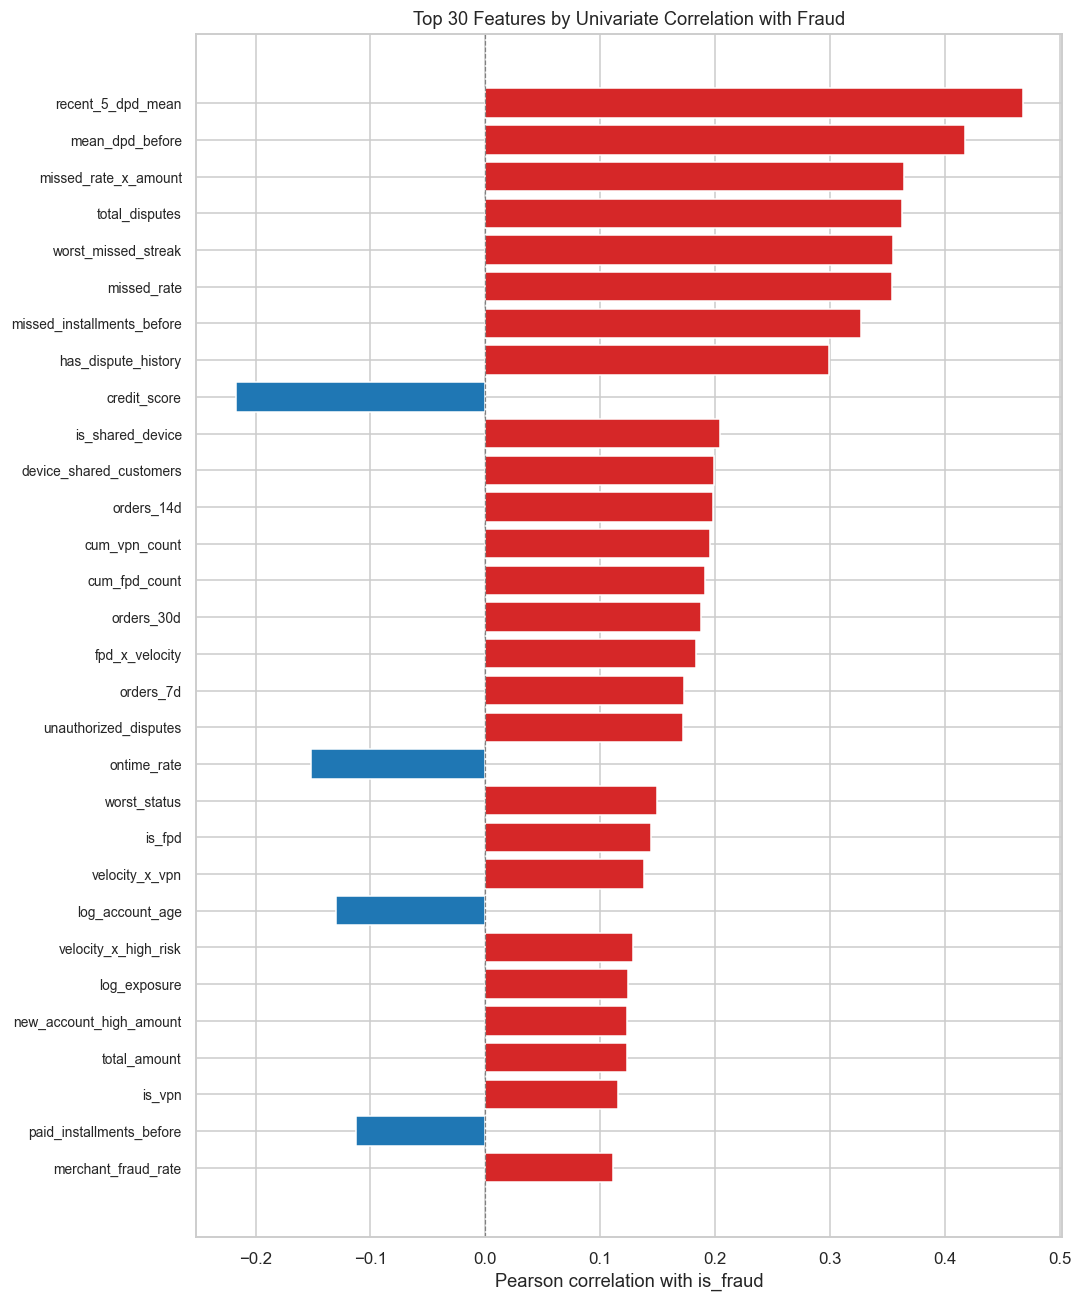


Top 15 features by absolute correlation:
recent_5_dpd_mean             0.467802
mean_dpd_before               0.417508
missed_rate_x_amount          0.364543
total_disputes                0.363014
worst_missed_streak           0.354556
missed_rate                   0.354318
missed_installments_before    0.326632
has_dispute_history           0.299188
credit_score                 -0.217339
is_shared_device              0.204414
device_shared_customers       0.198643
orders_14d                    0.197759
cum_vpn_count                 0.195975
cum_fpd_count                 0.190908
orders_30d                    0.187414


In [13]:
corr_with_target = (
    fm_numeric[feature_cols + ["is_fraud"]]
    .corr()["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 12))
top_n = min(30, len(corr_with_target))
top_corr = corr_with_target.head(top_n)
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top_corr.values]
ax.barh(range(top_n), top_corr.values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel("Pearson correlation with is_fraud")
ax.set_title("Top 30 Features by Univariate Correlation with Fraud")
ax.invert_yaxis()
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 15 features by absolute correlation:")
print(corr_with_target.head(15).to_string())

## Feature Distributions: Fraud vs. Legitimate

Correlation only tells us about linear relationships. For tree-based models (which we'll use downstream), what matters is *separability* — can the feature split fraud from non-fraud at some threshold? These density plots show the overlap between distributions. Features where the fraud distribution (red) is visibly shifted from the legitimate distribution (blue) will be most useful, even if the relationship isn't perfectly linear.

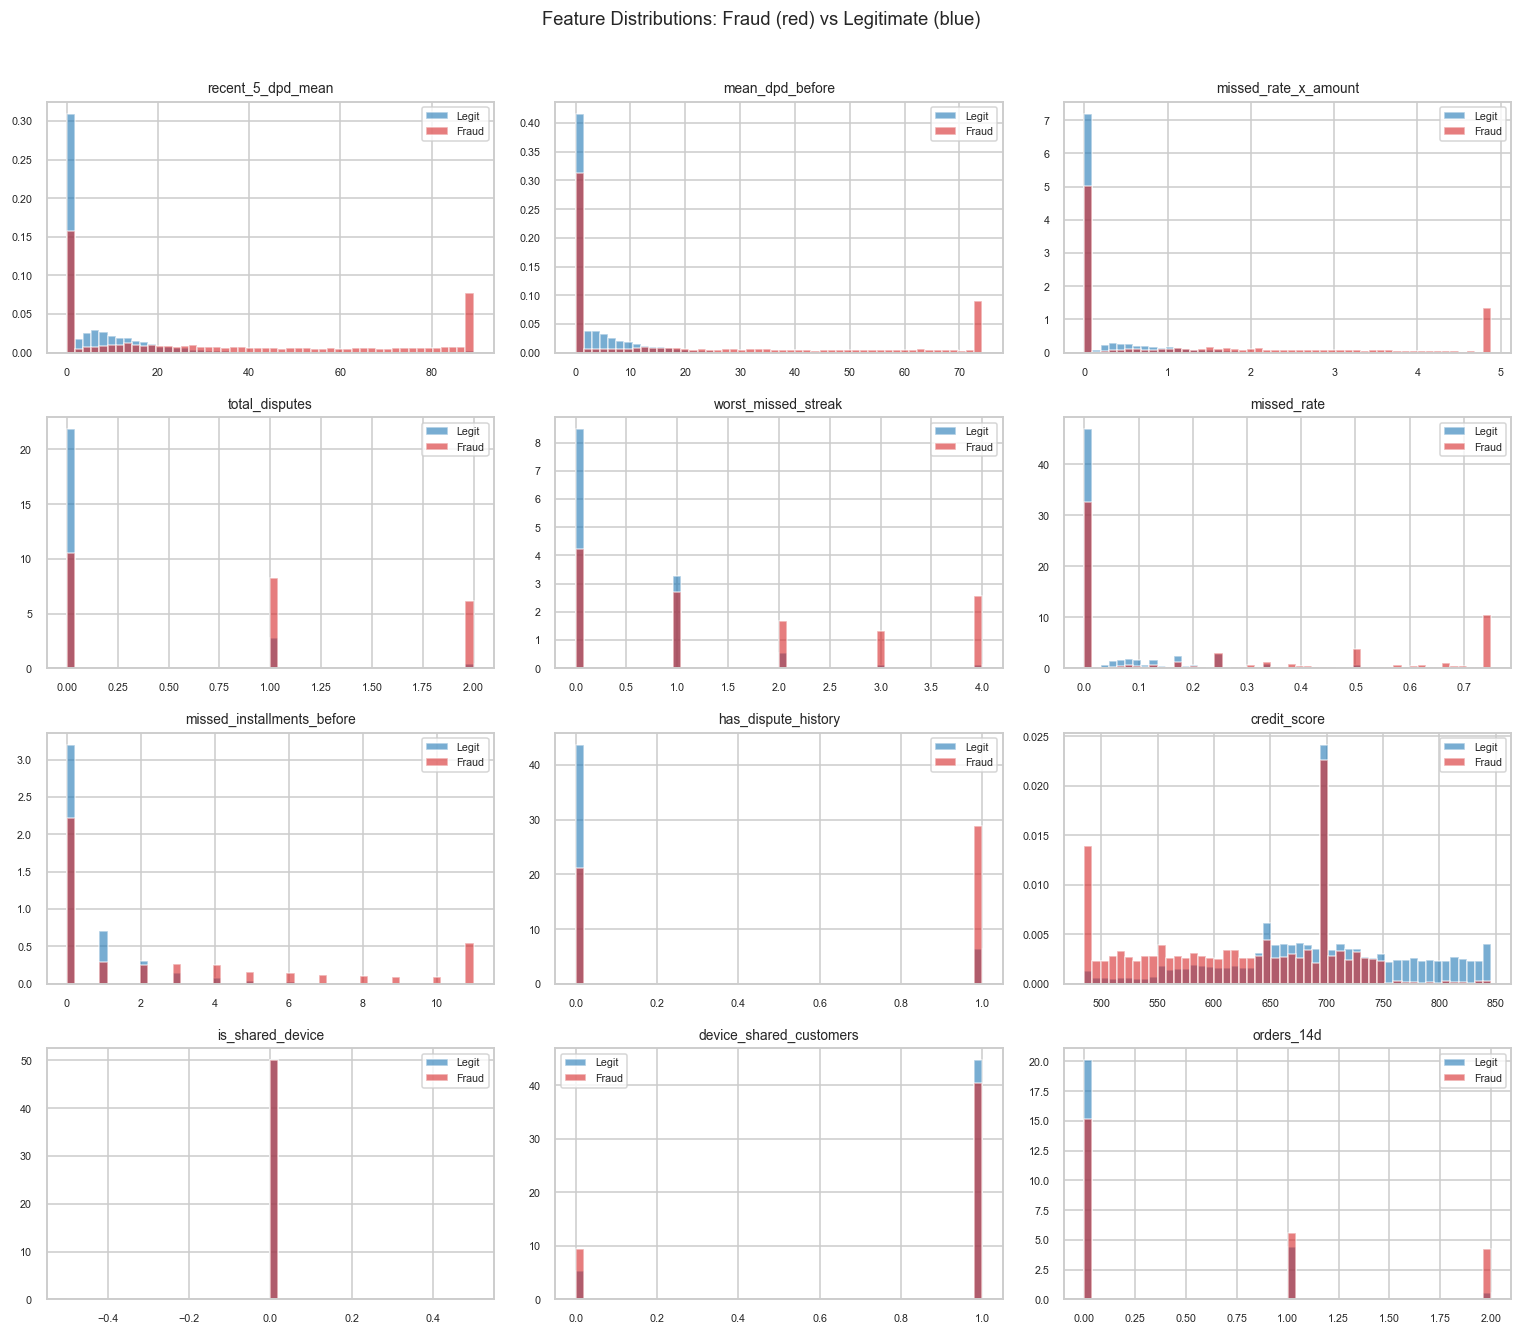

In [14]:
plot_features = corr_with_target.head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes_flat = axes.flatten()

for idx, feat in enumerate(plot_features):
    ax = axes_flat[idx]
    fraud_vals = fm_numeric.loc[fm_numeric["is_fraud"] == 1, feat]
    legit_vals = fm_numeric.loc[fm_numeric["is_fraud"] == 0, feat]

    p99 = fm_numeric[feat].quantile(0.99)
    p01 = fm_numeric[feat].quantile(0.01)

    ax.hist(legit_vals.clip(p01, p99), bins=50, alpha=0.6, density=True, color="#1f77b4", label="Legit")
    ax.hist(fraud_vals.clip(p01, p99), bins=50, alpha=0.6, density=True, color="#d62728", label="Fraud")
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Feature Distributions: Fraud (red) vs Legitimate (blue)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Feature Inter-correlation

Highly correlated feature pairs (|r| > 0.8) don't add independent information and can inflate feature importance in tree models. We check for problematic pairs here. If two features are near-duplicates (e.g., `cum_order_amount` and `exposure_at_order`), we'd drop one in the modeling notebook — but for now we keep both because different models may benefit from different representations.

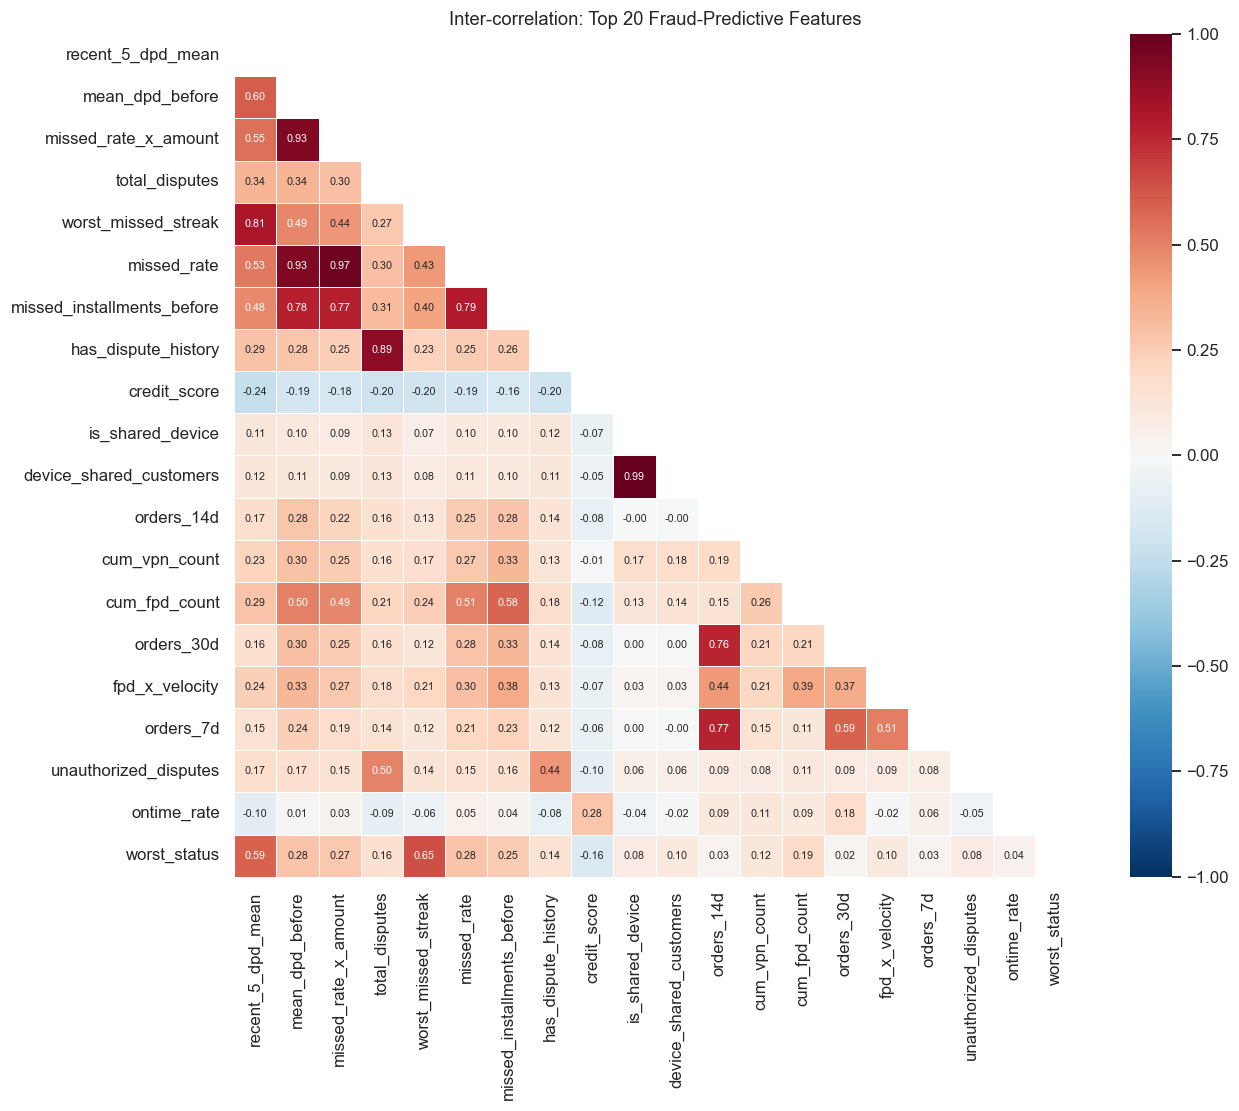

Highly correlated pairs (|r| > 0.8):
  is_shared_device <-> device_shared_customers: 0.993
  missed_rate_x_amount <-> missed_rate: 0.971
  mean_dpd_before <-> missed_rate: 0.930
  mean_dpd_before <-> missed_rate_x_amount: 0.928
  total_disputes <-> has_dispute_history: 0.892
  recent_5_dpd_mean <-> worst_missed_streak: 0.813


In [15]:
top_20_feats = corr_with_target.head(20).index.tolist()
corr_matrix = fm_numeric[top_20_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 7}, vmin=-1, vmax=1)
ax.set_title("Inter-correlation: Top 20 Fraud-Predictive Features")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("Highly correlated pairs (|r| > 0.8):")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {f1} <-> {f2}: {r:.3f}")
else:
    print("No feature pairs exceed |r| > 0.8 among top 20.")

## Wrapping Up

We've constructed a feature matrix with 50+ engineered features across 6 categories, all computed using vectorized pandas operations on 150K+ orders.

Key design choices to revisit in modeling:
- **`merchant_fraud_rate`** has mild label leakage — consider dropping or using a time-lagged version
- Several velocity features are correlated by construction (7d/14d/30d) — tree models handle this fine, but regularized linear models may need feature selection
- **`path_entropy`** and **`status_volatility`** capture similar information from different angles — keep both and let feature importance sort it out
- Channel dummies add dimensionality without strong univariate signal, but may interact with other features in meaningful ways
- The dispute features have a soft circularity (disputes can *be* fraud events) — monitor for leakage in validation

In [16]:
total_time = time.time() - t_start

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\nRows:     {fm_numeric.shape[0]:,}")
print(f"Features: {len(feature_cols)}")
print(f"Target:   is_fraud (rate = {fm_numeric['is_fraud'].mean():.3%})")
print(f"Output:   ../data/feature_matrix.csv")
print(f"Time:     {total_time:.1f}s")
print(f"\nFeature categories:")
print(f"  Payment behaviour:    ~10 features")
print(f"  Velocity/recency:     ~12 features")
print(f"  Device/network:       ~6 features")
print(f"  Merchant risk:        ~6 features")
print(f"  BNPL-specific:        ~8 features")
print(f"  State-path:           ~6 features")
print(f"  Customer profile:     ~8 features")
print(f"  Interactions:         ~6 features")
print(f"\nNull values remaining: {fm_numeric[feature_cols].isnull().sum().sum()}")
print(f"\nReady for modeling (notebook 05).")

FEATURE ENGINEERING COMPLETE

Rows:     155,750
Features: 72
Target:   is_fraud (rate = 6.069%)
Output:   ../data/feature_matrix.csv
Time:     49.1s

Feature categories:
  Payment behaviour:    ~10 features
  Velocity/recency:     ~12 features
  Device/network:       ~6 features
  Merchant risk:        ~6 features
  BNPL-specific:        ~8 features
  State-path:           ~6 features
  Customer profile:     ~8 features
  Interactions:         ~6 features

Null values remaining: 0

Ready for modeling (notebook 05).
